# Cyber Trend Forecasting - VisionTS++ Pipeline

**Vignette Description:**
This notebook acts as the Pipeline Dashboard for the project. It handles the end-to-end workflow:
1.  **Setup:** Automatically detects if running on Google Colab or the NATO Local Server.
2.  **Zero-Shot Forecast:** Executes `Evaluate_VisionPP.py` - the pretrained VisionTS++ model with chunked rendering.
3.  **Evaluation:** Generates metrics and predictions for all 1,231 dataset columns.
4.  **Visualisation:** Runs `Visualise_VisionPP_Results.py` and displays the Gap Analysis inline.
5.  **Multi-Model:** Re-runs the evaluation and all visualisations with the per-series multi-model combined forecast (the headline result).
6.  **Appendix:** Re-runs training to demonstrate that finetuning does not beat zero-shot.

## Universal Setup

This cell handles the setup logic: mounting Google Drive if on Colab, or using relative paths if on the GPU server

In [ ]:
import os
import sys
import contextlib

# --- CONFIGURATION ---
# If on Colab, ensure you have set the Secret 'project_path' to your Project Root
# e.g., /content/drive/MyDrive/NATO_Project_Root

try:
    # 1. CHECK ENVIRONMENT: Try to import Colab-specific modules
    from google.colab import drive, userdata
    IS_COLAB = True
    print("--- Detected Environment: GOOGLE COLAB ---")
except ImportError:
    IS_COLAB = False
    print("--- Detected Environment: LOCAL SERVER (NATO/BBK) ---")

# 2. PATH SETUP
if IS_COLAB:
    # --- COLAB SETUP ---
    try:
        drive.mount('/content/drive')

        # Get the PARENT ROOT from Secrets
        PROJECT_ROOT = userdata.get('project_path')
        if not PROJECT_ROOT:
            raise ValueError("Secret 'project_path' is missing.")

    except Exception as e:
        print(f"COLAB SETUP ERROR: {e}")
        # Stop execution if we can't find the files
        raise e
else:
    # --- LOCAL SETUP ---
    # We assume this notebook is in 'Notebooks/', so Root is one level up
    # os.getcwd() returns /.../Project_Root/Notebooks
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 3. CONFIGURE WORKING DIRECTORY
# We need to run scripts from inside 'Transformer_Pipeline'
PIPELINE_DIR = os.path.join(PROJECT_ROOT, 'Transformer_Pipeline')

if not os.path.exists(PIPELINE_DIR):
    raise FileNotFoundError(f"Could not find pipeline folder at: {PIPELINE_DIR}")

# Change CWD to the pipeline folder so scripts can find config/data
os.chdir(PIPELINE_DIR)
print(f"SUCCESS: Working Directory set to: {os.getcwd()}")

# 4. ADD PROJECT ROOT TO SYS.PATH
# This allows us to import 'Notebooks.colab_utils' if needed
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print(f"Added Project Root to sys.path: {PROJECT_ROOT}")

# 5. INSTALL DEPENDENCIES (COLAB ONLY)
if IS_COLAB:
    print("\n--- Installing Dependencies (Colab Only) ---")
    # We import the helper script from the sibling folder
    try:
        from Notebooks import Colab_Utils
        # This creates a temporary black hole for the print statements
        with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f):
            Colab_Utils.setup_environment(PIPELINE_DIR)
        print("Dependencies verified successfully!")
    except ImportError:
        print("WARNING: Could not import Notebooks.colab_utils. Skipping auto-install.")

# On Apple Silicon, enable the fallback for unsupported MPS ops:
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

### Imports

In [ ]:
from pathlib import Path

from Transformer_Pipeline.Visualise_VisionPP_Results import (
    visualise_evaluation_metrics,
    load_visualisation_data,
    perform_broad_analysis,
    plot_validation_forecasts,
    generate_gap_analysis_tables,
    plot_continuous_trends
)

DATASET = "v2_2_full"

## Optional: Re-Generate Vision Data

Run this cell if you want to rebuild the preprocessed windows from the raw CSV data. If you have already processed the data, you can skip this step.

In [ ]:
# Runs the preprocessing scripts to generate the VisionTS++ artifacts
# We use !python to run these as clean subprocesses

# We are currently in the 'Transformer_Pipeline' directory.
# The scripts will resolve paths automatically.

!{sys.executable} -W ignore -m Preprocessing.Cyber_Trend_to_Image \
    --dataset v2_2_full --window-first \
    --feature-names-file Preprocessing/v2_2_all_features_1231.txt 2>/dev/null
!{sys.executable} -W ignore -m Preprocessing.Cyber_Trend_to_Image_PP \
    --dataset v2_2_full --force 2>/dev/null

## Step 1: Zero-Shot Forecast (VisionTS++)

We now execute the forecasting script.
- **Input:** `Cyber_Trend_VisionPP_Config.py` (per-dataset defaults: chunk_size=6, periodicity=1, num_patch_input=7)
- **Output:** `visionpp_predictions.npy` (forecasts for all 1,231 columns)

The model is the pretrained VisionTS++ (MAE-base) with inference-time chunked rendering. The "WARNING: No checkpoint found" message is EXPECTED - it confirms the model runs zero-shot from pretrained weights. The Appendix demonstrates overfit during training.

*Note: On first run the pretrained checkpoint (~450 MB) is downloaded from HuggingFace. Inference takes ~5 minutes on GPU.*

In [ ]:
print("--- Step 1: Zero-Shot Forecast (VisionTS++) ---")
%run Evaluate_VisionPP.py --dataset v2_2_full

## Step 2: Evaluation & Metrics

The forecast step above already ran the model against the Test Set.
* It calculates **RSE, RAE, MAE, and CORR** across horizons (3, 6, 12, 24 months).
* It saves the raw predictions to `.npy` files for visualisation.
* It exports the results to a CSV file.

--- Step 2: Evaluation Metrics (zero-shot) ---

--- PUBLICATION PREVIEW: Evaluation Metrics ---

--- Generating Evaluation Metrics Table ---


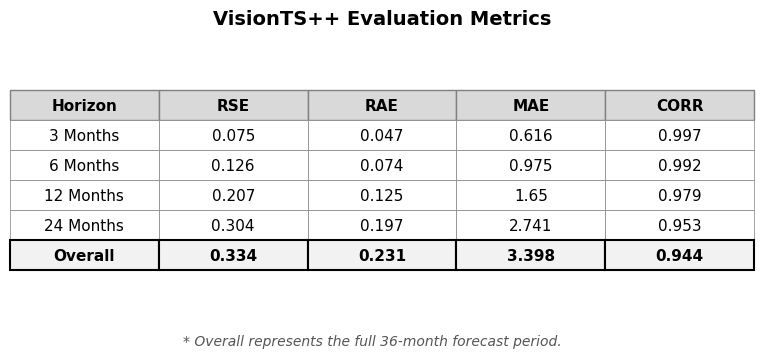

Saved: Vision_Eval_Table.png (and archived to archive/)


In [5]:
print("--- Step 2: Evaluation Metrics (zero-shot) ---")

print("\n--- PUBLICATION PREVIEW: Evaluation Metrics ---")
visualise_evaluation_metrics(dataset=DATASET)

## Step 3: Visualise Results

This section executes the visualisation pipeline to interpret the VisionTS++ model's output. 

### Setup & Data Loading

In [ ]:
current_dir = Path.cwd()
if str(current_dir.parent) not in sys.path: sys.path.append(str(current_dir.parent))

# Load data into vis_data
vis_data = load_visualisation_data(dataset=DATASET)

if vis_data: print("Data Loaded Successfully.")
else: print("Failed to load data.")

### Broad Analysis: Global Trends
This cell generates two high-level aggregate plots to assess the overall state of the cybersecurity landscape:

* **Global Forecast Accuracy:** Compares the **Global Average Ground Truth** (Black) against the **Global Average Prediction** (Blue) across all nodes. This provides a macroscopic view of the model's reliability.
* **Global Gap Analysis (Threat Intensity vs Mitigation Maturity):** Plots the **Average Threat Intensity** (Red) against the **Average Mitigation Maturity** (Green) for the entire dataset.
    * **Risk Gap (Red Shading):** Indicates periods where threats generally outpace available solutions.
    * **Safety Margin (Green Shading):** Indicates periods where defense maturity exceeds threat intensity.


--- FORECAST ACCURACY: Ground Truth vs Prediction ---


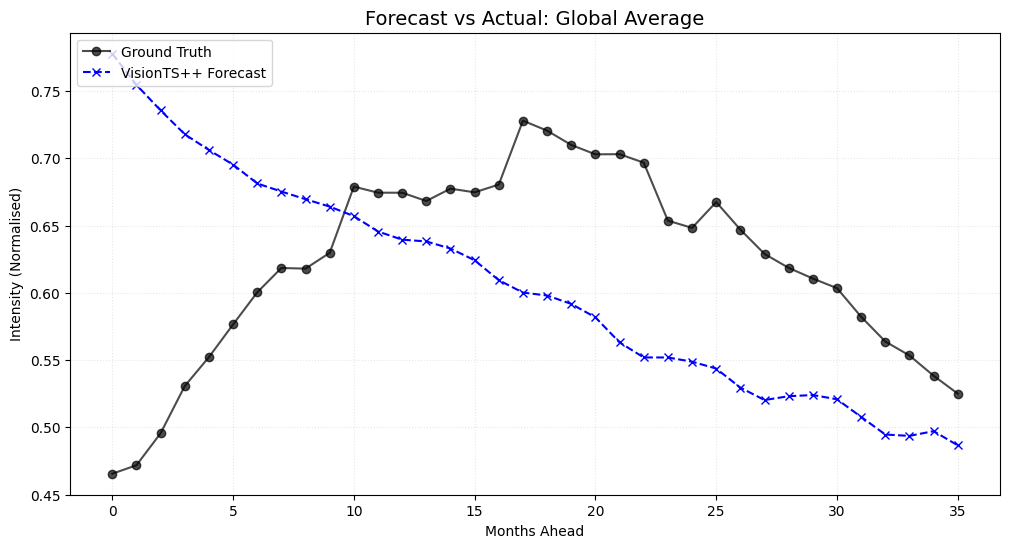

Saved: Global_Forecast_Accuracy.png (and archived to archive/)

--- GAP ANALYSIS: Threat vs Mitigation ---


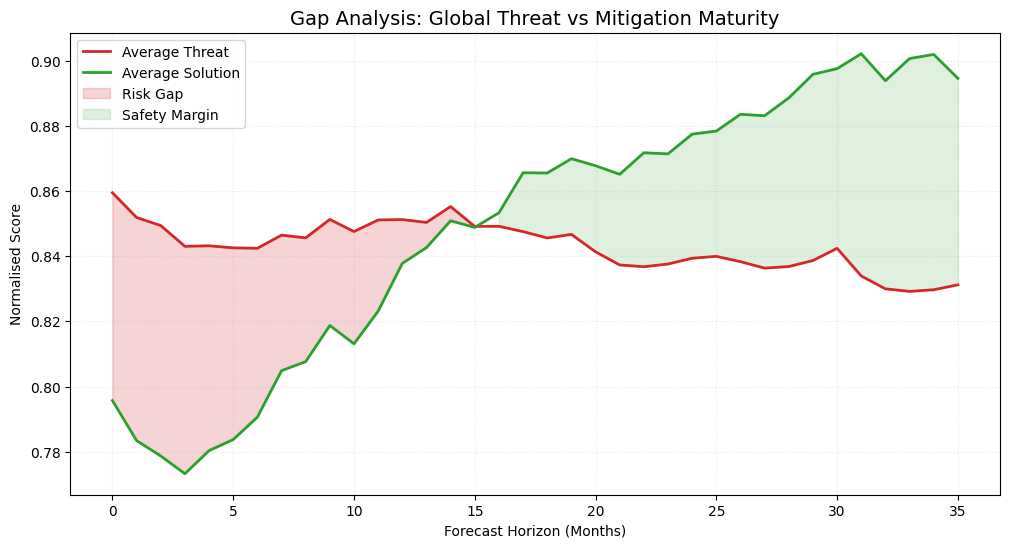

Saved: Global_Gap_Analysis.png (and archived to archive/)


In [7]:
if vis_data:
    perform_broad_analysis(vis_data)

### Forecast Accuracy (Ground Truth vs Prediction)
This cell generates the validation plots corresponding to **Figure 3** in the paper. It visualises the model's performance on specific, high-priority validation nodes (e.g., *Password Attack*, *NLP/LLM*, *Data Backups*).

* **Visuals:** It plots the **Actual Ground Truth** (Blue Line) versus the **VisionTS++ Forecast** (Purple Dashed Line) over the test period.
* **Confidence:** The shaded region represents the **95% Confidence Interval** of the prediction.


--- Figure 3: Forecast Accuracy (Ground Truth vs Prediction) ---


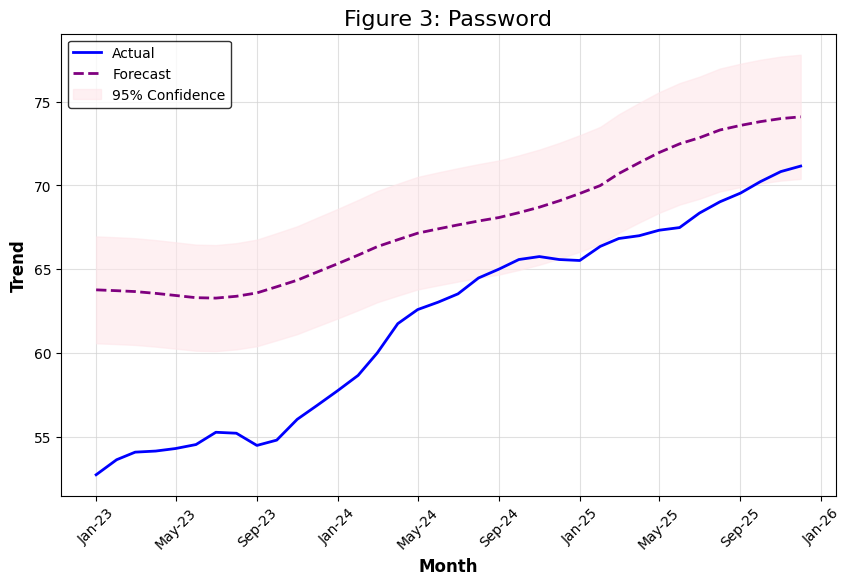

Saved: Fig3_Password.png (and archived to archive/)


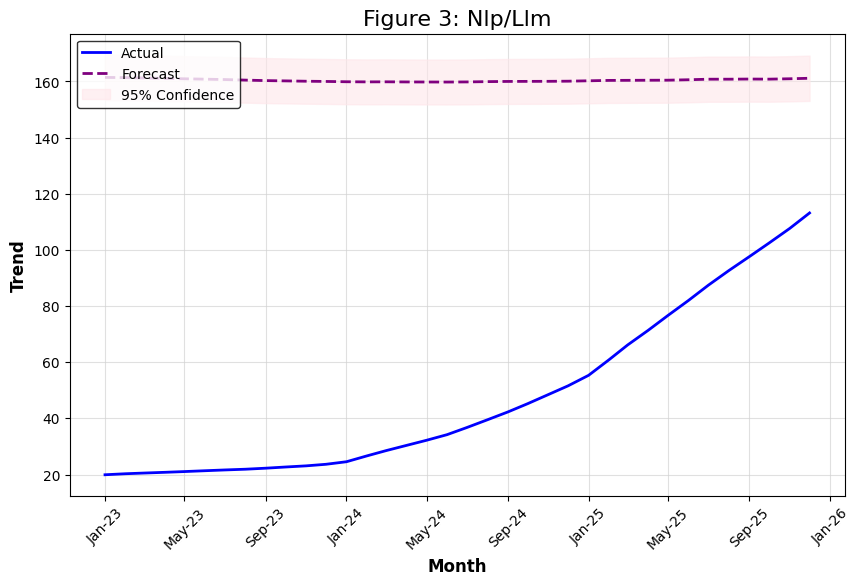

Saved: Fig3_Nlp_Llm.png (and archived to archive/)


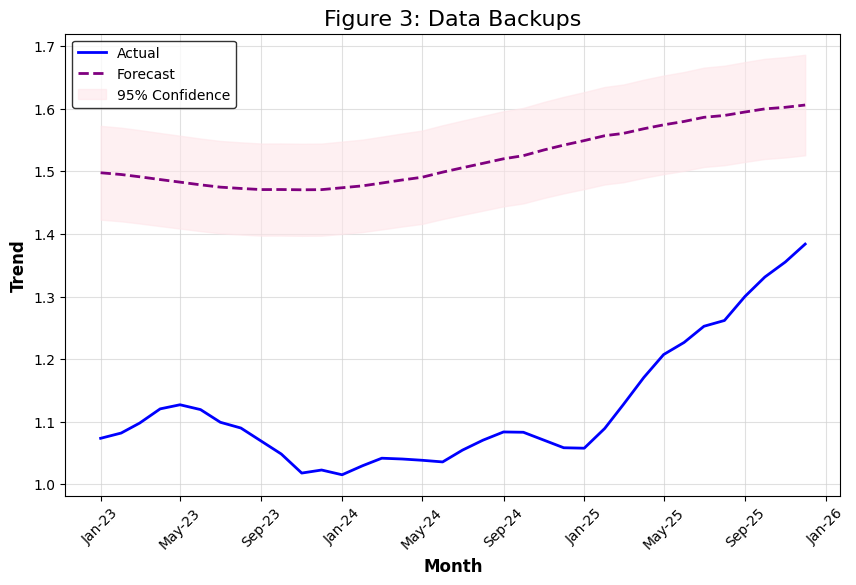

Saved: Fig3_Data_Backups.png (and archived to archive/)


In [8]:
if vis_data:
    plot_validation_forecasts(vis_data)

### Gap Analysis Tables (Tables 5 & 6)
This cell performs a quantitative analysis of the "Risk Gap" defined in the paper. It calculates the numerical difference between Threat Intensity and Solution Maturity for every pair in the knowledge graph over the forecast window (2023-2025).

* **Table 5 (Widening Gaps):** Identifies pairs where the gap is increasing year-over-year (Strictly Widening) or is larger at the end of the period than the start (Overall Widening). These represent emerging risks.
* **Table 6 (Narrowing Gaps):** Identifies pairs where the gap is decreasing, indicating "Success Stories" where mitigation strategies are effectively catching up to the threat.


--- GAP TABLES: Widening & Narrowing ---


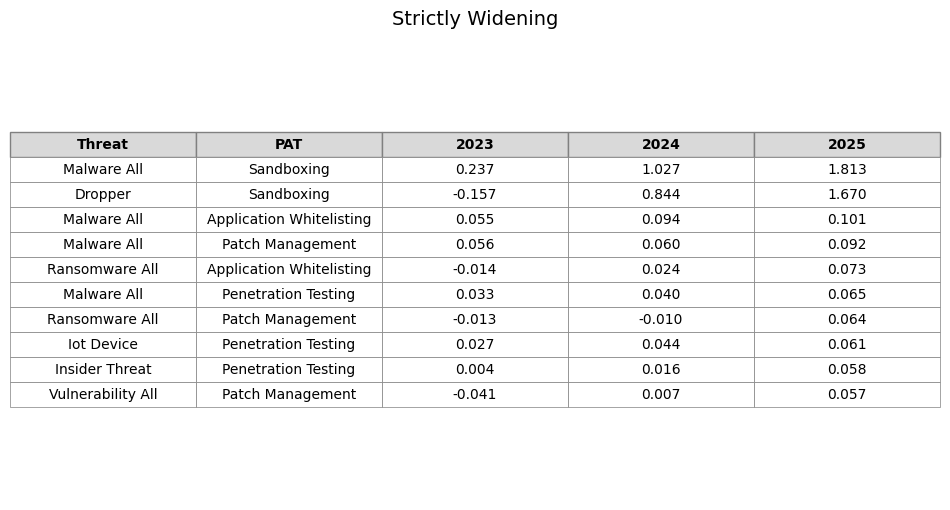

Saved: Strictly_Widening.png (and archived to archive/)

--- Table 5a: Strictly Widening Gaps (Top 5) ---
        Threat                      PAT   2023  2024  2025
   Malware All               Sandboxing  0.237 1.027 1.813
       Dropper               Sandboxing -0.157 0.844 1.670
   Malware All Application Whitelisting  0.055 0.094 0.101
   Malware All         Patch Management  0.056 0.060 0.092
Ransomware All Application Whitelisting -0.014 0.024 0.073


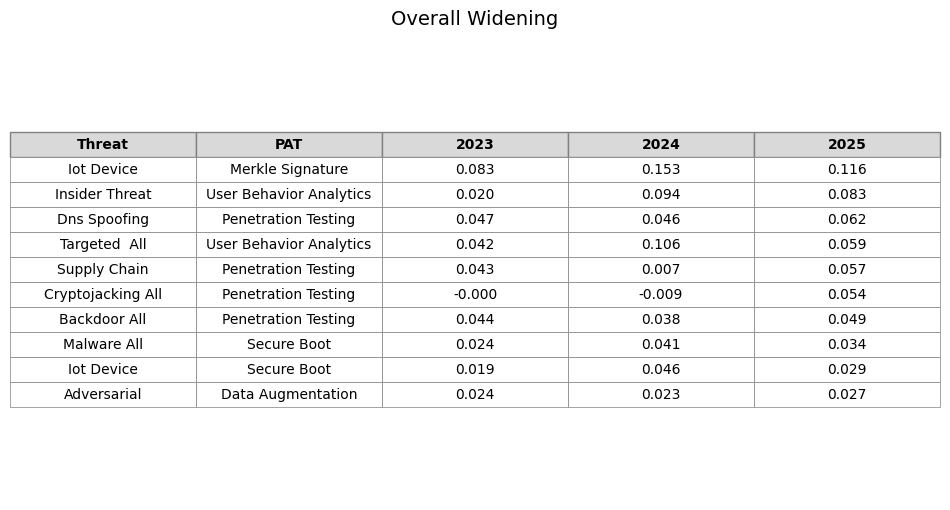

Saved: Overall_Widening.png (and archived to archive/)

--- Table 5b: Overall Widening Gaps (Top 5) ---
        Threat                     PAT  2023  2024  2025
    Iot Device        Merkle Signature 0.083 0.153 0.116
Insider Threat User Behavior Analytics 0.020 0.094 0.083
  Dns Spoofing     Penetration Testing 0.047 0.046 0.062
 Targeted  All User Behavior Analytics 0.042 0.106 0.059
  Supply Chain     Penetration Testing 0.043 0.007 0.057


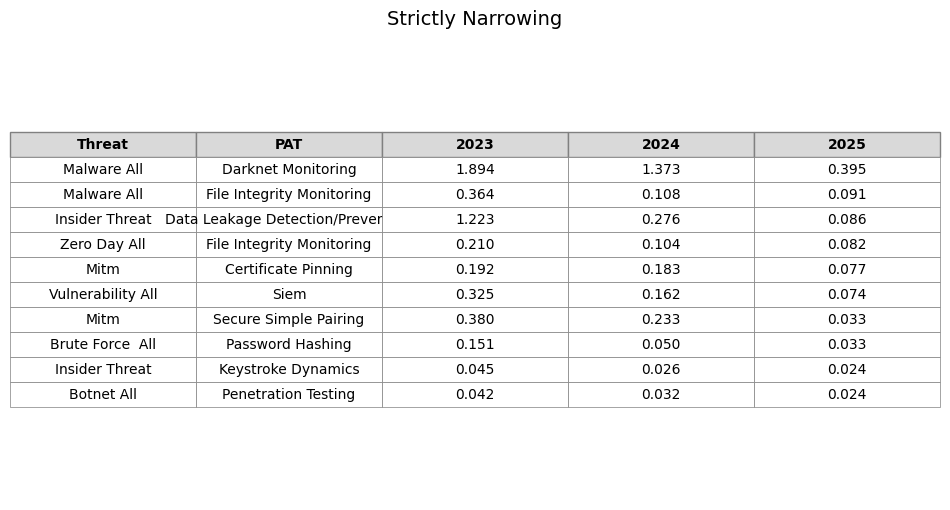

Saved: Strictly_Narrowing.png (and archived to archive/)

--- Table 6a: Strictly Narrowing Gaps (Top 5) ---
        Threat                               PAT  2023  2024  2025
   Malware All                Darknet Monitoring 1.894 1.373 0.395
   Malware All         File Integrity Monitoring 0.364 0.108 0.091
Insider Threat Data Leakage Detection/Prevention 1.223 0.276 0.086
  Zero Day All         File Integrity Monitoring 0.210 0.104 0.082
          Mitm               Certificate Pinning 0.192 0.183 0.077


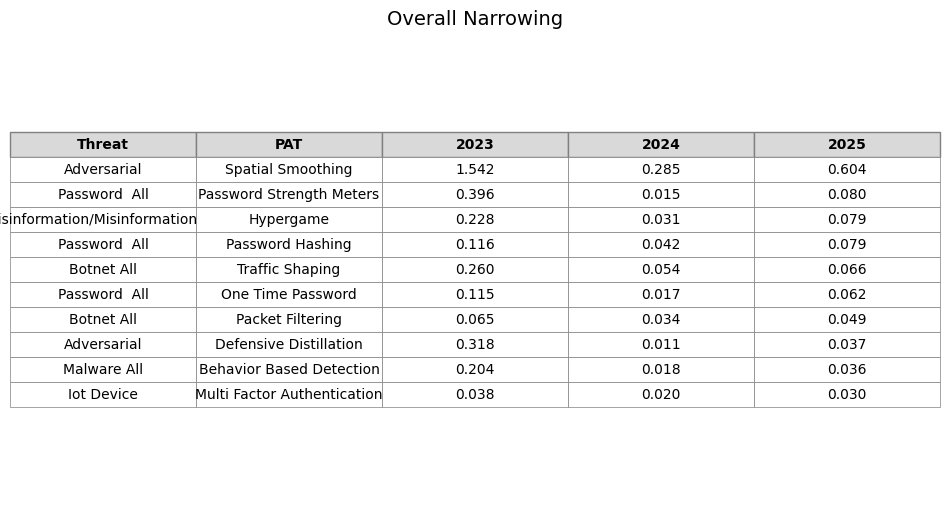

Saved: Overall_Narrowing.png (and archived to archive/)

--- Table 6b: Overall Narrowing Gaps (Top 5) ---
                           Threat                      PAT  2023  2024  2025
                      Adversarial        Spatial Smoothing 1.542 0.285 0.604
                    Password  All Password Strength Meters 0.396 0.015 0.080
Disinformation/Misinformation All                Hypergame 0.228 0.031 0.079
                    Password  All         Password Hashing 0.116 0.042 0.079
                       Botnet All          Traffic Shaping 0.260 0.054 0.066


In [9]:
if vis_data:
  generate_gap_analysis_tables(vis_data)

### Continuous Trends (2011-2028)
This cell generates **Figure 4**, which stitches the historical data (2011-2022) with the model's forecast (2023-2028) to visualise the continuous 14-year evolution of major threat vectors (e.g., *Malware*, *Ransomware*).

* **The Trend:** The Black Line represents the continuous trend from the past into the future.
* **The Forecast:** The future period (2023-2025) includes 95% confidence shading.
* **Mitigation Context:** Where applicable, relevant solution trends (Green/Blue lines) are plotted alongside the threat to visualise the long-term interaction between attack vectors and defense mechanisms.


--- PAPER FIG 4: Continuous Trends ---


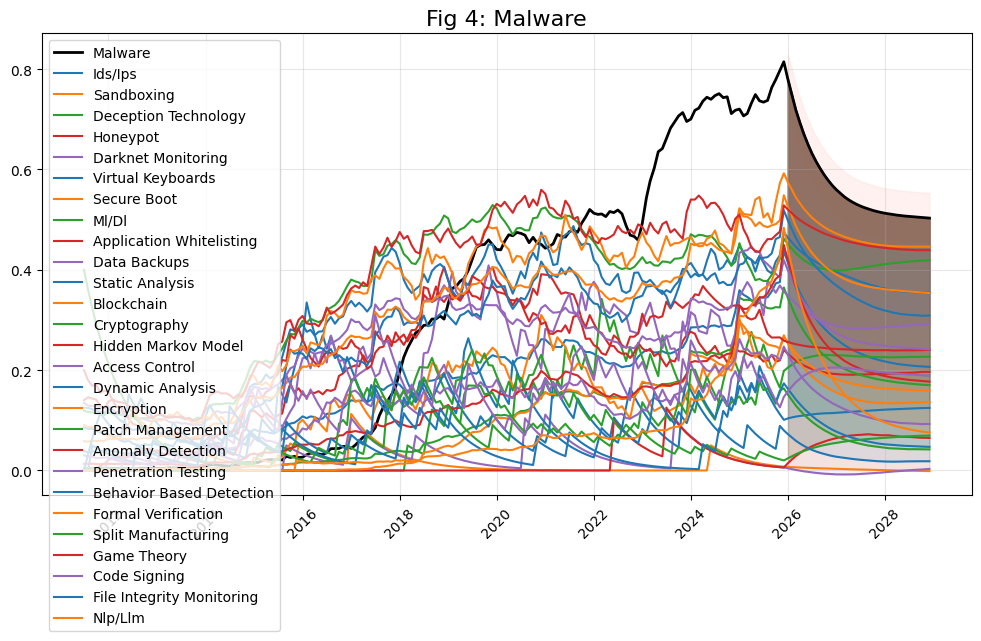

Saved: Fig4_Malware.png (and archived to archive/)


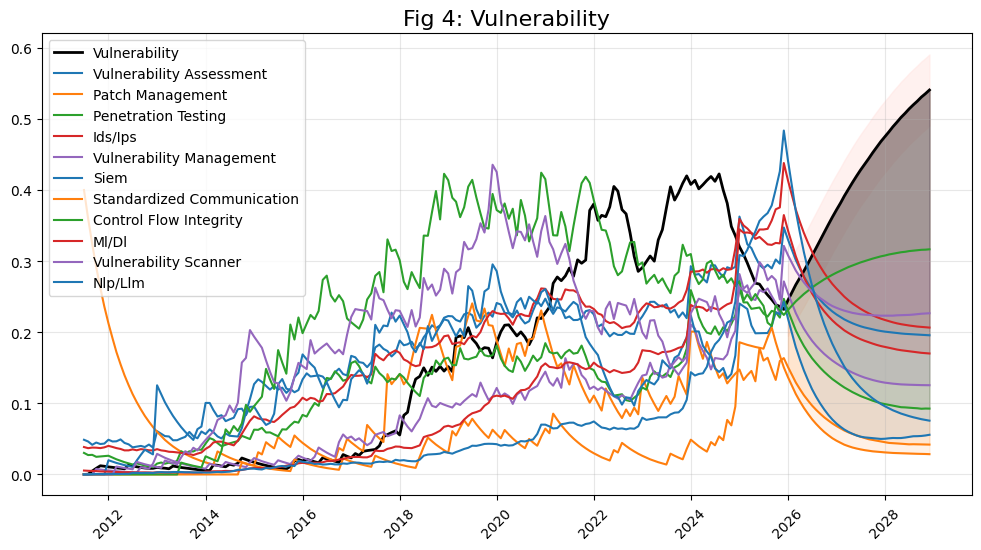

Saved: Fig4_Vulnerability.png (and archived to archive/)


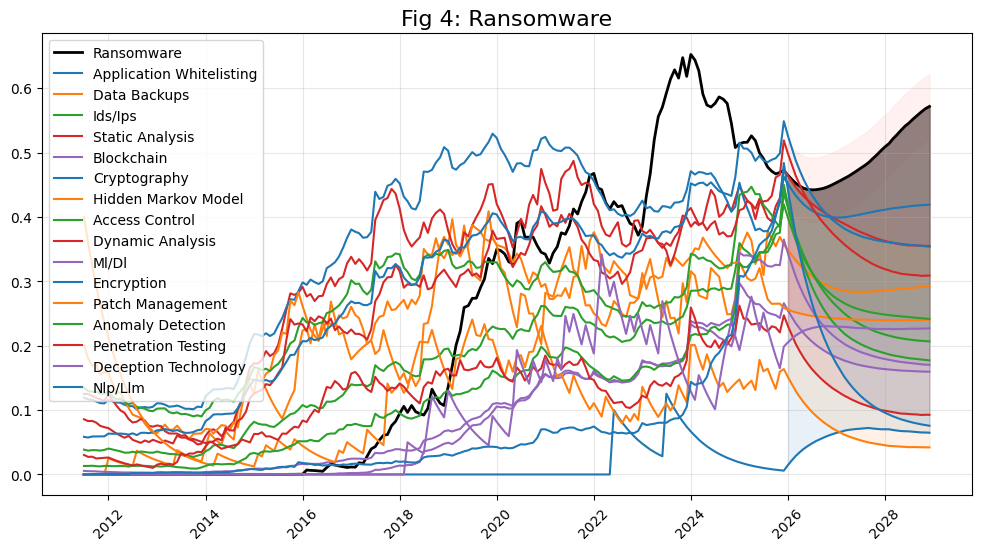

Saved: Fig4_Ransomware.png (and archived to archive/)


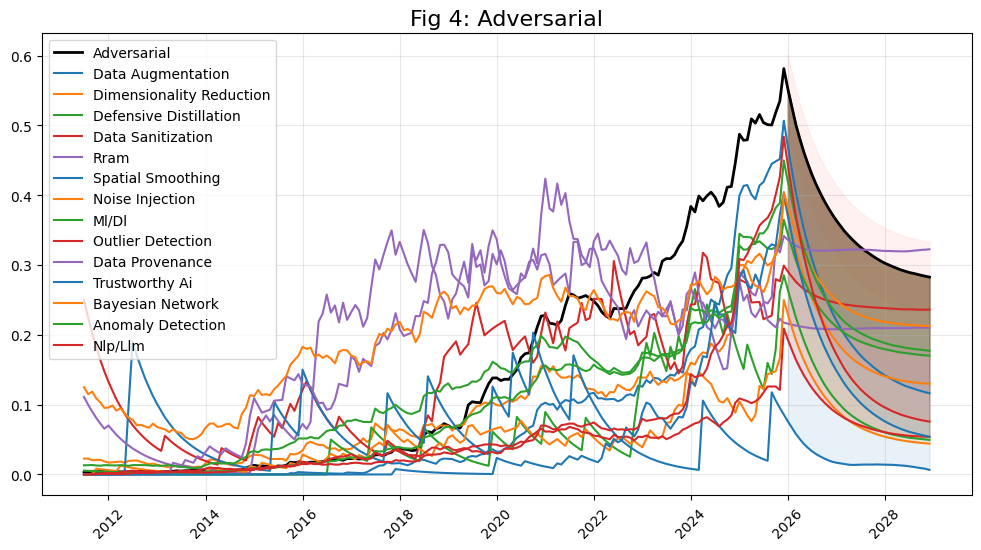

Saved: Fig4_Adversarial.png (and archived to archive/)


In [10]:
if vis_data:
    plot_continuous_trends(vis_data)

## Multi-Model: Re-Run Everything with the Headline Combined Forecast

The multi-model forecast is the best result. It keeps the zero-shot VisionTS++ forecast everywhere it wins and reassigns individual (feature, horizon-band) cells of the 159-feature benchmark subset to a better causal candidate where the validation split says so - a seasonal(periodicity-12) rendering, per-series SARIMA, or SARIMAX with 12-month-LAGGED Reddit war/conflict signals.

The cells below run the multi-model selection, combine its output into the prediction arrays, and then re-run   the evaluation metrics and all four visualisations on the multi-model forecasts. A pure zero-shot backup is saved alongside.

In [ ]:
MULTI_MODEL_DIR = os.path.join('Results', 'v2_2_full', 'experiments', 'multi_model')

print("--- Multi-Model: candidate forecasts ---")
!{sys.executable} {os.path.join(MULTI_MODEL_DIR, 'multi_model_phase1.py')}

print("\n--- Multi-Model: SARIMA / SARIMAX-lagged-Reddit candidates ---")
!{sys.executable} {os.path.join(MULTI_MODEL_DIR, 'multi_model_phase2.py')}

print("\n--- Multi-Model: selection (val only) + single test evaluation ---")
!{sys.executable} {os.path.join(MULTI_MODEL_DIR, 'multi_model_phase3.py')}

Multi-model combined forecast saved: 159 benchmark columns reassigned, 1072 columns unchanged zero-shot.
Evaluation CSV recomputed from the multi-model forecasts.

--- PUBLICATION PREVIEW: Evaluation Metrics (multi-model) ---

--- Generating Evaluation Metrics Table ---


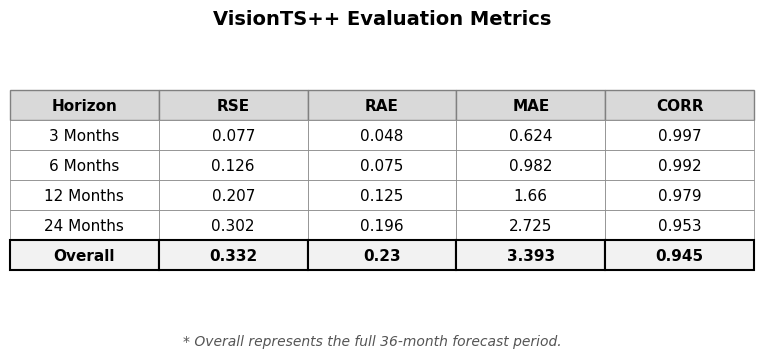

Saved: Vision_Eval_Table.png (and archived to archive/)


In [12]:
import numpy as np
import pandas as pd

# Combine the multi-model benchmark forecasts into the full-width prediction arrays.
RESULTS_DIR = os.path.join('Results', 'v2_2_full')
preds = np.load(os.path.join(RESULTS_DIR, 'visionpp_predictions.npy'))
trues = np.load(os.path.join(RESULTS_DIR, 'visionpp_ground_truth.npy'))

# keep a pure zero-shot backup next to the canonical arrays
np.save(os.path.join(RESULTS_DIR, 'visionpp_predictions_zeroshot.npy'), preds)

full_names = [str(n) for n in np.load(
    os.path.join('..', 'Processed_Data', 'visionpp', 'v2_2_full', 'feature_names.npy'),
    allow_pickle=True)]
with open(os.path.join('Preprocessing', 'v2_1_selected_features_159.txt')) as f:
    bench_names = [l.strip() for l in f if l.strip()]
bench = np.array([full_names.index(n) for n in bench_names])

mm_bench = np.load(os.path.join(MULTI_MODEL_DIR, 'test_pred_multi_model.npy'))
preds_mm = preds.copy()
preds_mm[:, :, bench] = mm_bench
np.save(os.path.join(RESULTS_DIR, 'visionpp_predictions.npy'), preds_mm)
print(f'Multi-model combined forecast saved: {len(bench)} benchmark columns reassigned, '
      f'{len(full_names) - len(bench)} columns unchanged zero-shot.')

# Recompute the evaluation CSV from the multi-model arrays (mirrors Evaluate_VisionPP).
rows = []
for h, hname in [(3, '3 Months'), (6, '6 Months'), (12, '12 Months'),
                 (24, '24 Months'), (36, 'Overall')]:
    p, t = preds_mm[:, :h, :].ravel(), trues[:, :h, :].ravel()
    mae = float(np.mean(np.abs(p - t)))
    rows.append({'Horizon': hname,
                 'RSE': float(np.sqrt(np.mean((p - t) ** 2) / (np.var(t) + 1e-7))),
                 'RAE': mae / (float(np.mean(np.abs(t - t.mean()))) + 1e-7),
                 'MAE': mae,
                 'CORR': float(np.corrcoef(p, t)[0, 1])})
pd.DataFrame(rows).to_csv(os.path.join(RESULTS_DIR, 'visionpp_evaluation_results.csv'),
                          index=False)
print('Evaluation CSV recomputed from the multi-model forecasts.')

print("\n--- PUBLICATION PREVIEW: Evaluation Metrics (multi-model) ---")
visualise_evaluation_metrics(dataset=DATASET)

In [ ]:
# Reload vis_data so all visualisations below use the MULTI-MODEL forecasts
vis_data = load_visualisation_data(dataset=DATASET)

if vis_data:
  print("Multi-model data Loaded Successfully.")
else:
  print("Failed to load data.")


--- FORECAST ACCURACY: Ground Truth vs Prediction ---


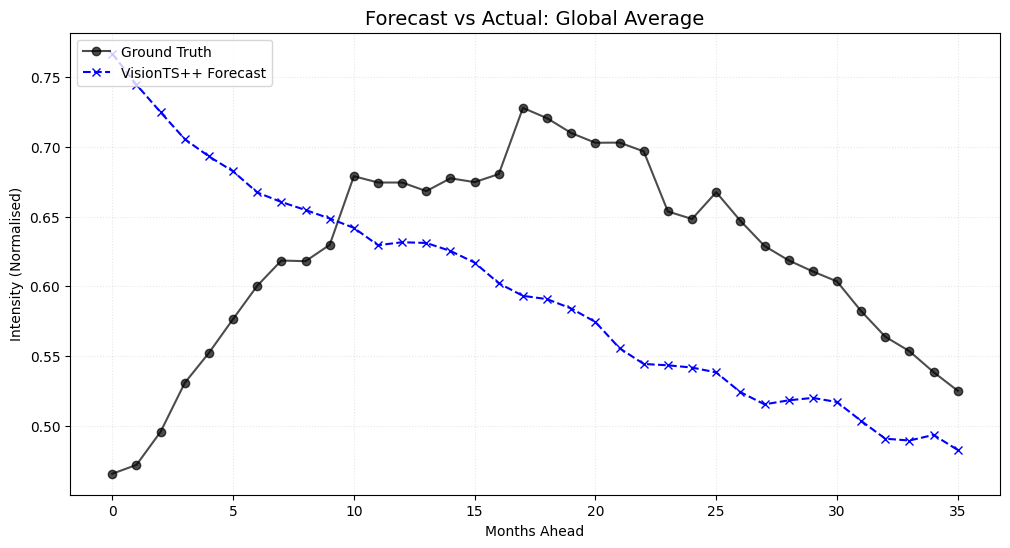

Saved: Global_Forecast_Accuracy.png (and archived to archive/)

--- GAP ANALYSIS: Threat vs Mitigation ---


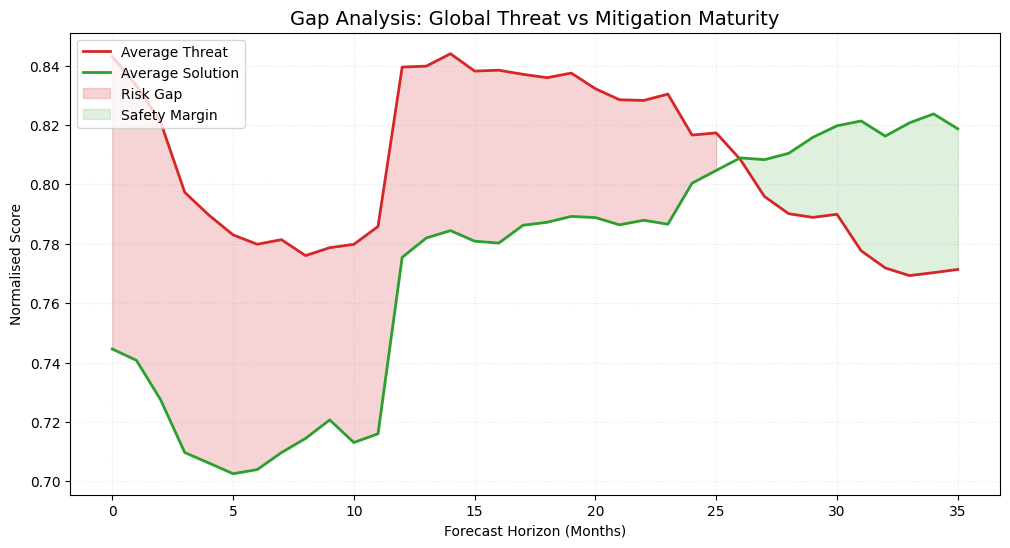

Saved: Global_Gap_Analysis.png (and archived to archive/)


In [14]:
if vis_data:
    perform_broad_analysis(vis_data)


--- Figure 3: Forecast Accuracy (Ground Truth vs Prediction) ---


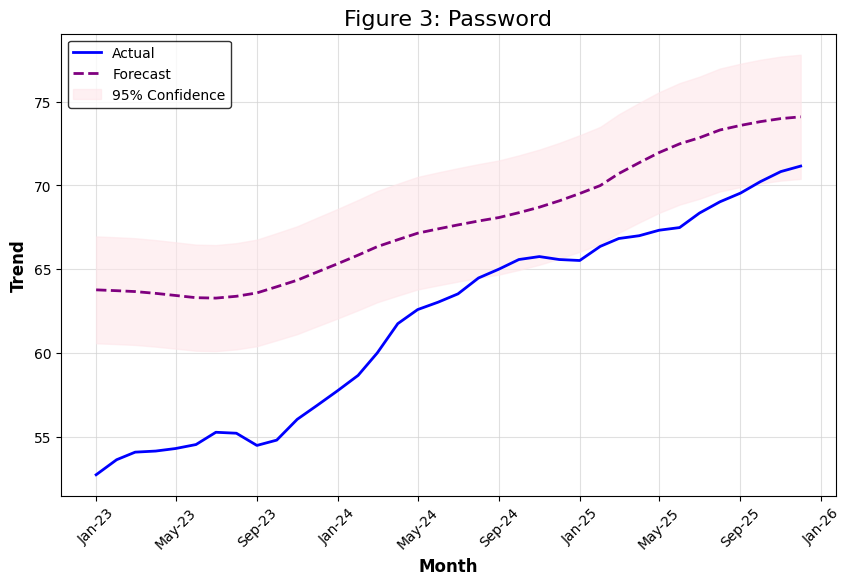

Saved: Fig3_Password.png (and archived to archive/)


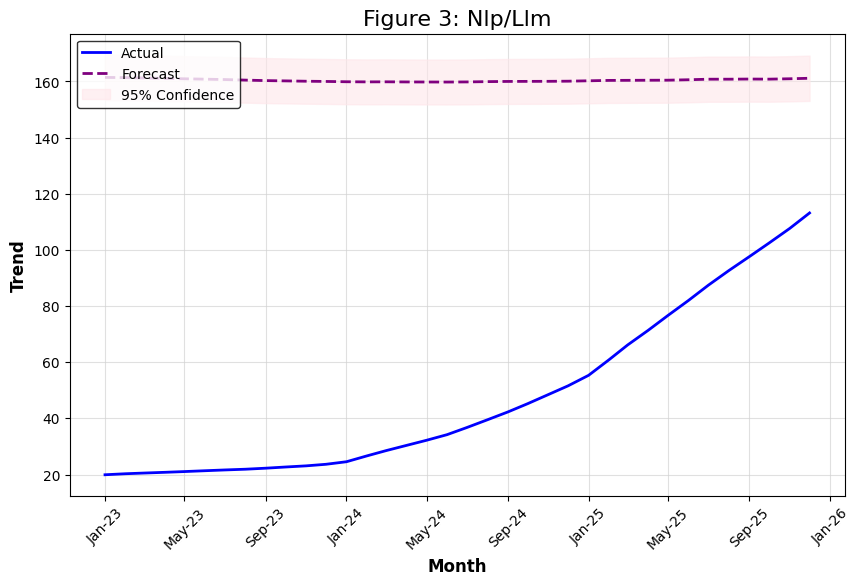

Saved: Fig3_Nlp_Llm.png (and archived to archive/)


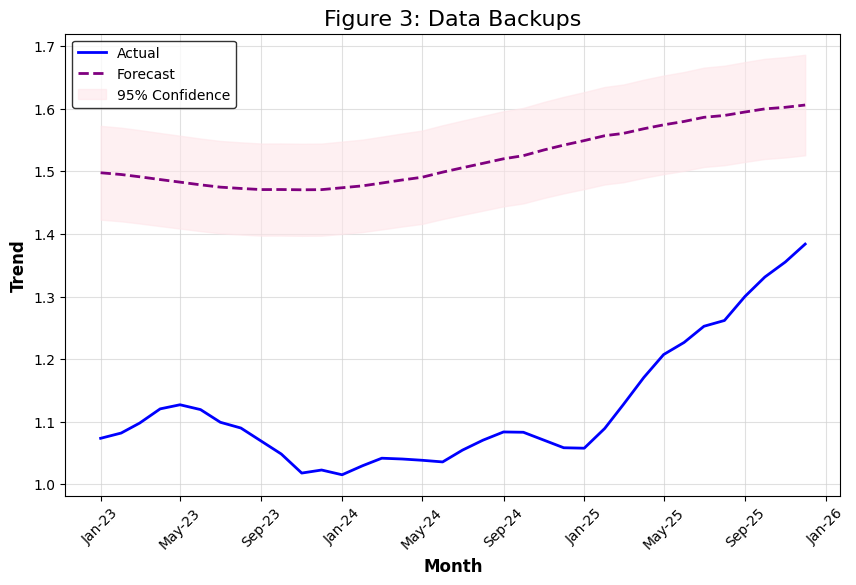

Saved: Fig3_Data_Backups.png (and archived to archive/)


In [15]:
if vis_data:
    plot_validation_forecasts(vis_data)


--- GAP TABLES: Widening & Narrowing ---


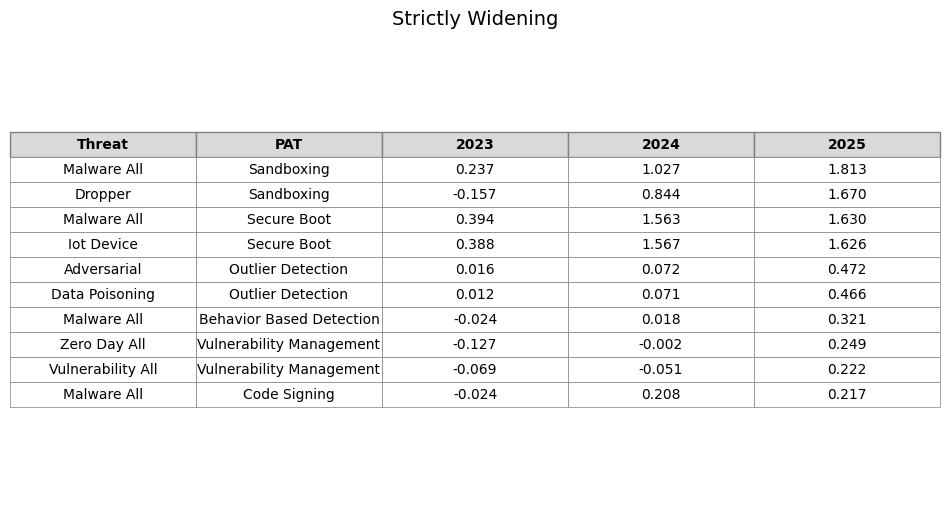

Saved: Strictly_Widening.png (and archived to archive/)

--- Table 5a: Strictly Widening Gaps (Top 5) ---
     Threat               PAT   2023  2024  2025
Malware All        Sandboxing  0.237 1.027 1.813
    Dropper        Sandboxing -0.157 0.844 1.670
Malware All       Secure Boot  0.394 1.563 1.630
 Iot Device       Secure Boot  0.388 1.567 1.626
Adversarial Outlier Detection  0.016 0.072 0.472


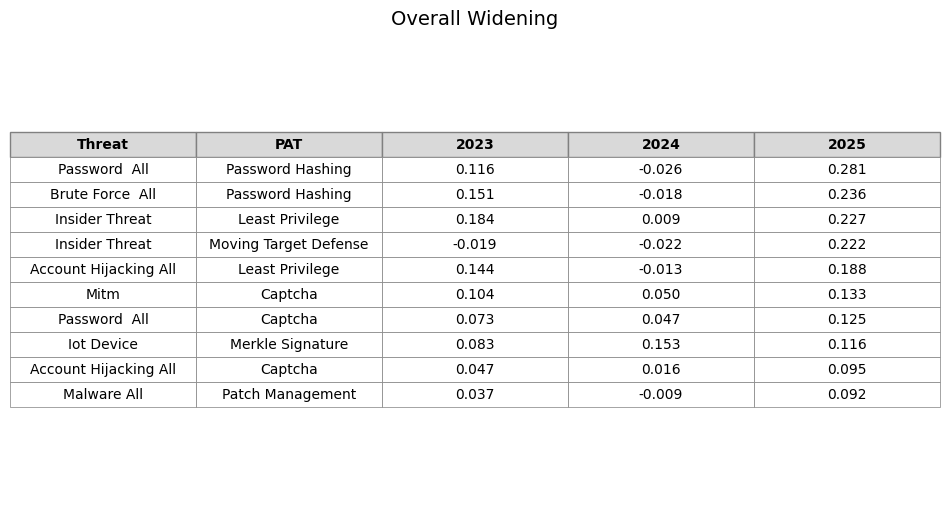

Saved: Overall_Widening.png (and archived to archive/)

--- Table 5b: Overall Widening Gaps (Top 5) ---
               Threat                   PAT   2023   2024  2025
        Password  All      Password Hashing  0.116 -0.026 0.281
     Brute Force  All      Password Hashing  0.151 -0.018 0.236
       Insider Threat       Least Privilege  0.184  0.009 0.227
       Insider Threat Moving Target Defense -0.019 -0.022 0.222
Account Hijacking All       Least Privilege  0.144 -0.013 0.188


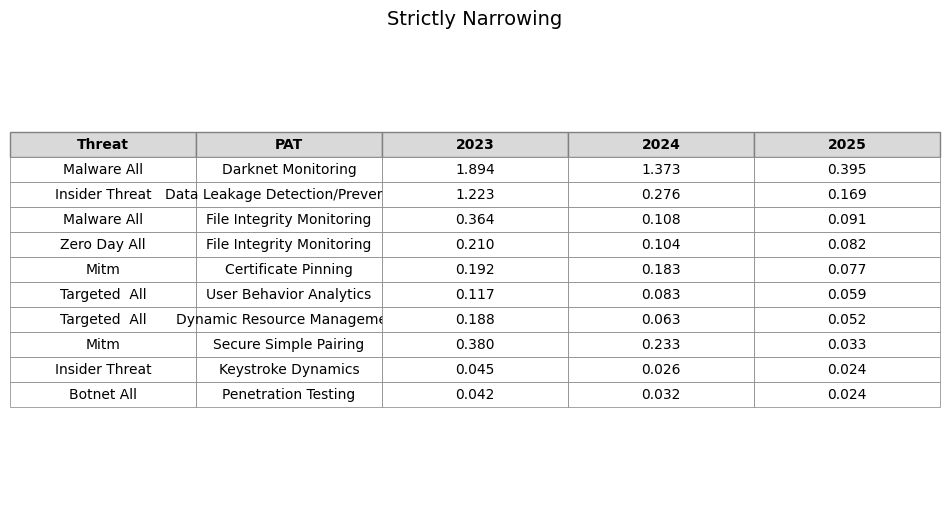

Saved: Strictly_Narrowing.png (and archived to archive/)

--- Table 6a: Strictly Narrowing Gaps (Top 5) ---
        Threat                               PAT  2023  2024  2025
   Malware All                Darknet Monitoring 1.894 1.373 0.395
Insider Threat Data Leakage Detection/Prevention 1.223 0.276 0.169
   Malware All         File Integrity Monitoring 0.364 0.108 0.091
  Zero Day All         File Integrity Monitoring 0.210 0.104 0.082
          Mitm               Certificate Pinning 0.192 0.183 0.077


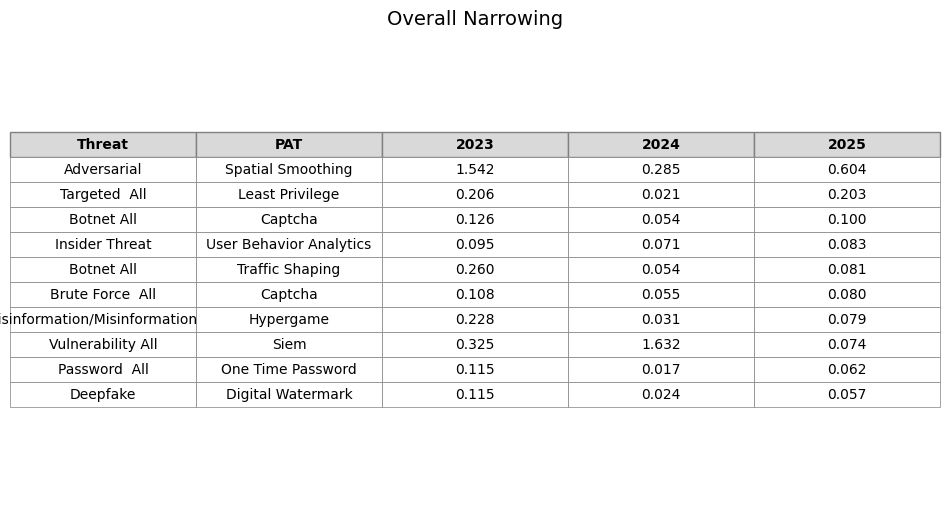

Saved: Overall_Narrowing.png (and archived to archive/)

--- Table 6b: Overall Narrowing Gaps (Top 5) ---
        Threat                     PAT  2023  2024  2025
   Adversarial       Spatial Smoothing 1.542 0.285 0.604
 Targeted  All         Least Privilege 0.206 0.021 0.203
    Botnet All                 Captcha 0.126 0.054 0.100
Insider Threat User Behavior Analytics 0.095 0.071 0.083
    Botnet All         Traffic Shaping 0.260 0.054 0.081


In [16]:
if vis_data:
  generate_gap_analysis_tables(vis_data)


--- PAPER FIG 4: Continuous Trends ---


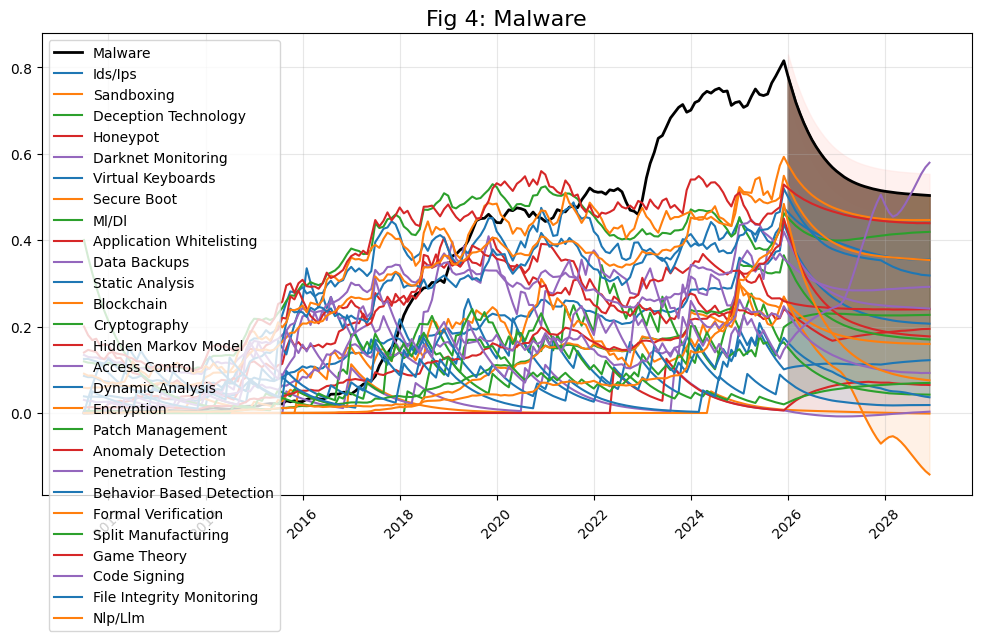

Saved: Fig4_Malware.png (and archived to archive/)


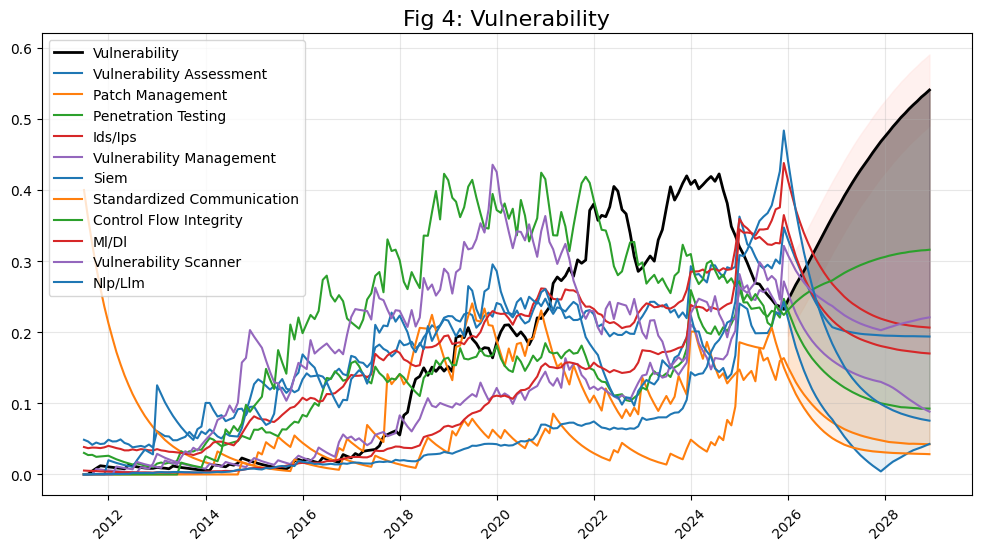

Saved: Fig4_Vulnerability.png (and archived to archive/)


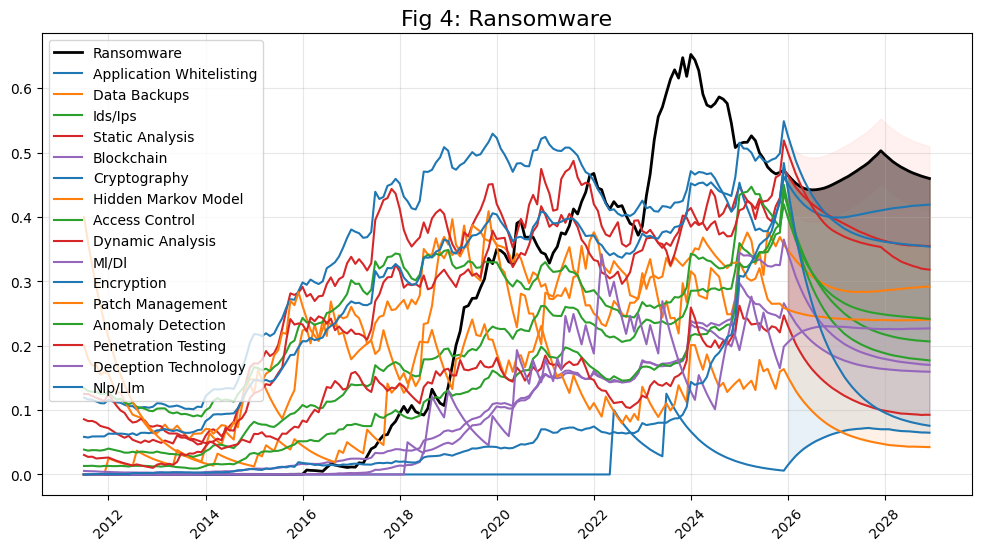

Saved: Fig4_Ransomware.png (and archived to archive/)


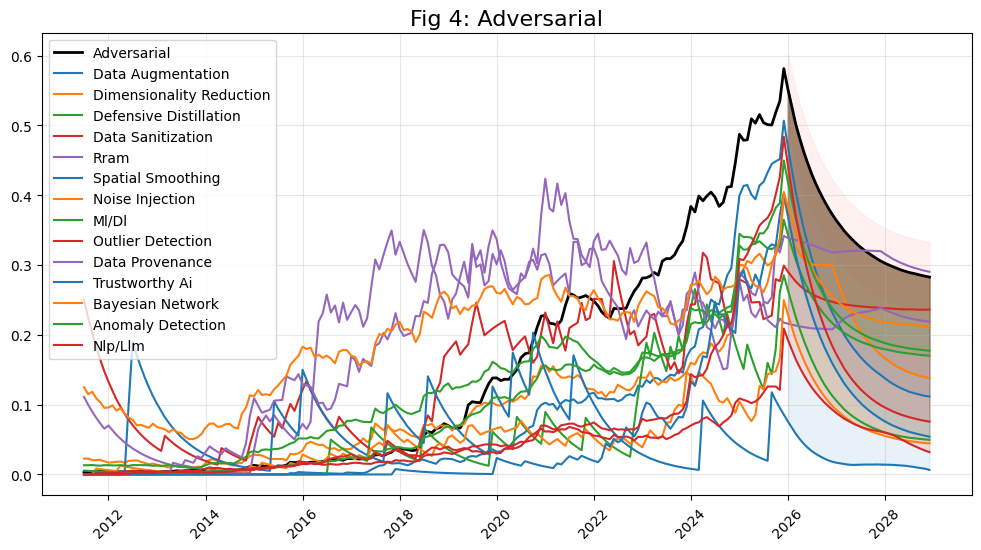

Saved: Fig4_Adversarial.png (and archived to archive/)


In [17]:
if vis_data:
    plot_continuous_trends(vis_data)

### Execute Full Pipeline
This cell executes the entire `Visualise_VisionPP_Results.py` script in one go using the `%run` command.

Using `%run` here ensures that the visualisation functions and loaded data remain accessible in the notebook session for further inspection if needed.

--- Loading Visualisation Data ---
Loading Full History from: Data_Preparation/Cyber_Trend_Forecasting_All_v2_2_sarimax.csv

--- FORECAST ACCURACY: Ground Truth vs Prediction ---


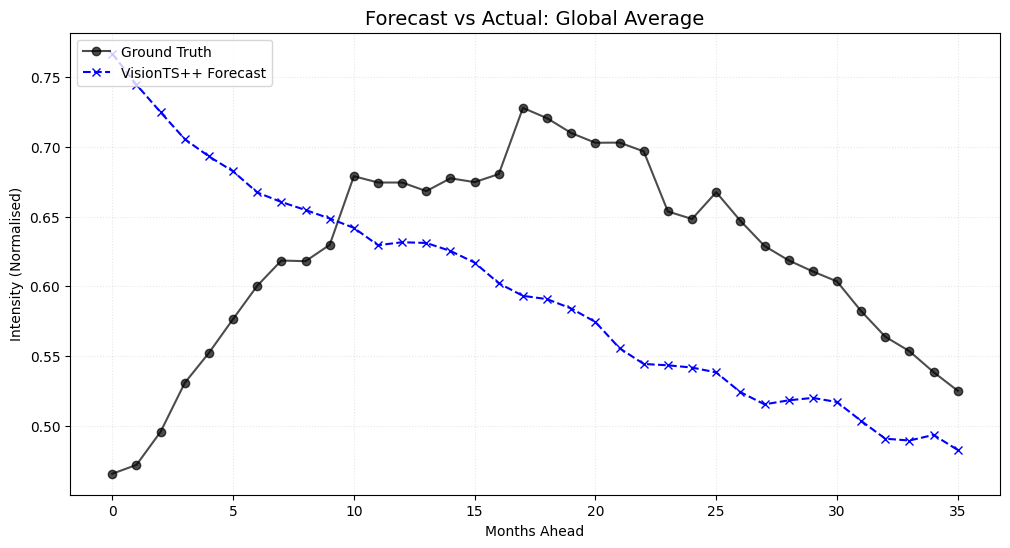

Saved: Global_Forecast_Accuracy.png (and archived to archive/)

--- GAP ANALYSIS: Threat vs Mitigation ---


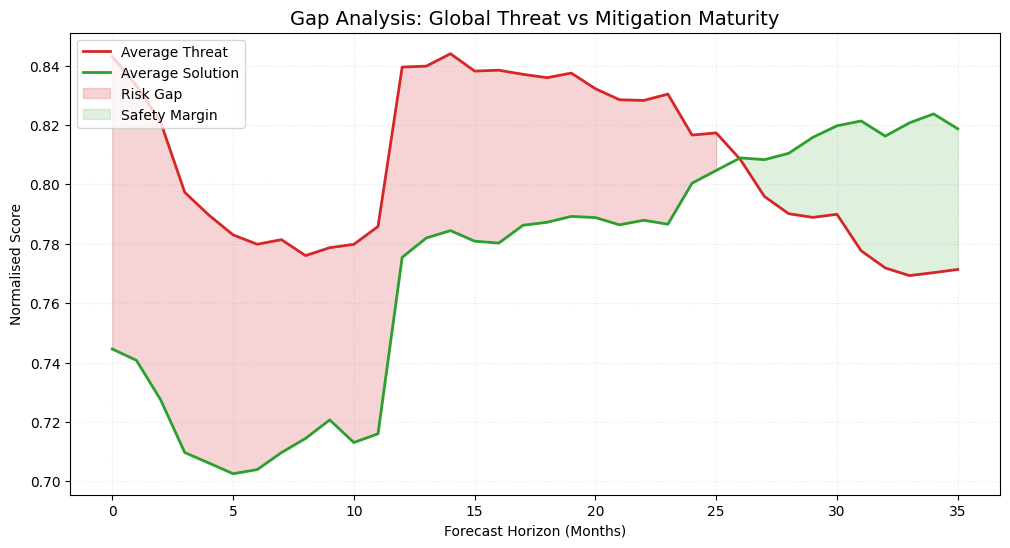

Saved: Global_Gap_Analysis.png (and archived to archive/)

--- Figure 3: Forecast Accuracy (Ground Truth vs Prediction) ---


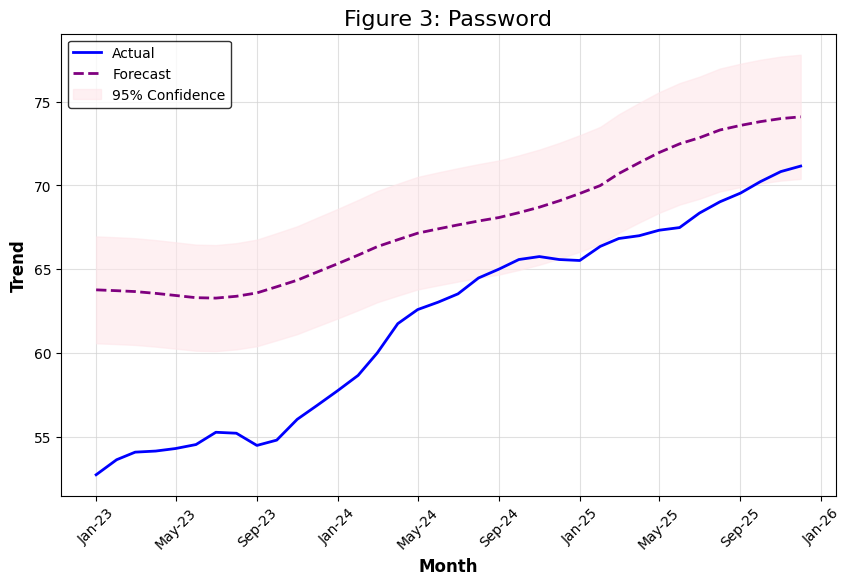

Saved: Fig3_Password.png (and archived to archive/)


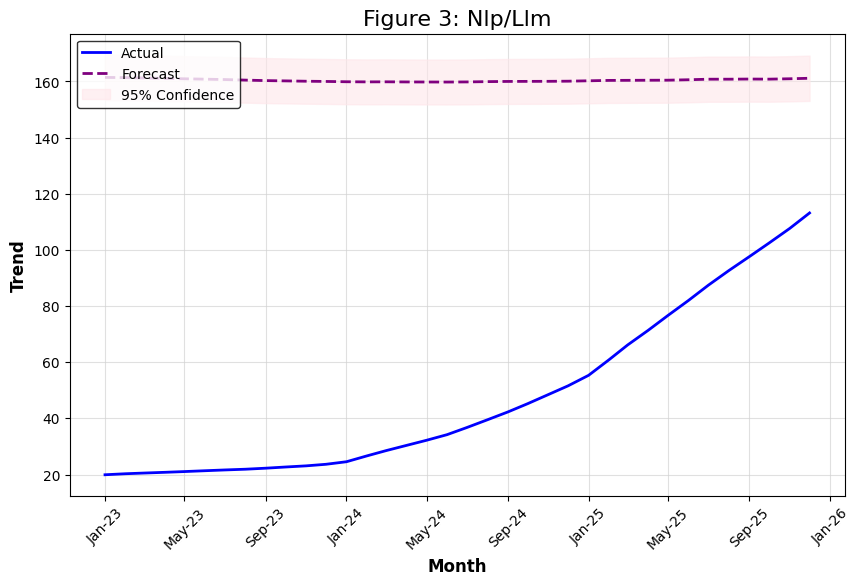

Saved: Fig3_Nlp_Llm.png (and archived to archive/)


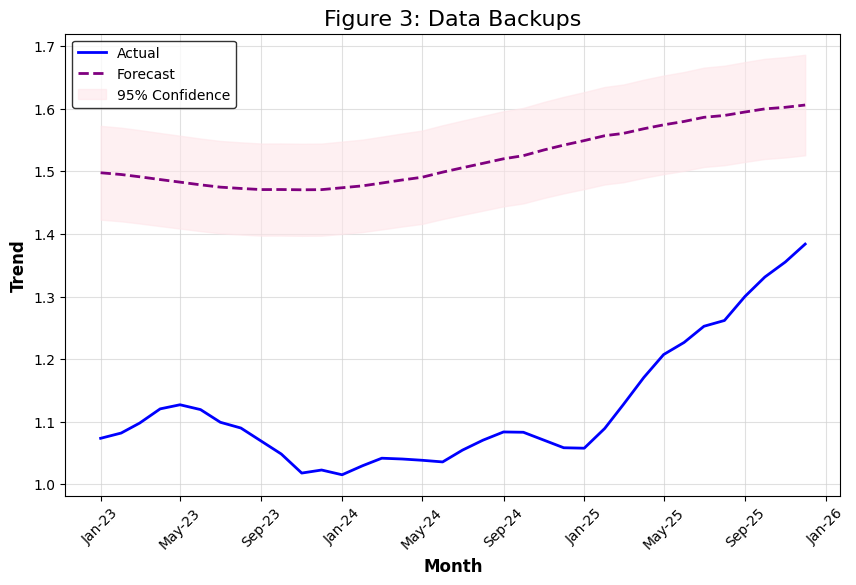

Saved: Fig3_Data_Backups.png (and archived to archive/)

--- GAP TABLES: Widening & Narrowing ---


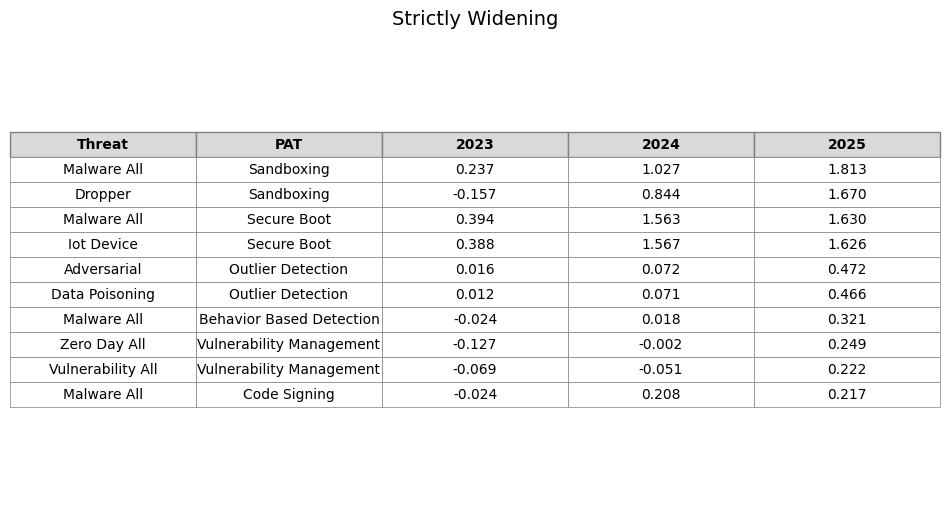

Saved: Strictly_Widening.png (and archived to archive/)

--- Table 5a: Strictly Widening Gaps (Top 5) ---
     Threat               PAT   2023  2024  2025
Malware All        Sandboxing  0.237 1.027 1.813
    Dropper        Sandboxing -0.157 0.844 1.670
Malware All       Secure Boot  0.394 1.563 1.630
 Iot Device       Secure Boot  0.388 1.567 1.626
Adversarial Outlier Detection  0.016 0.072 0.472


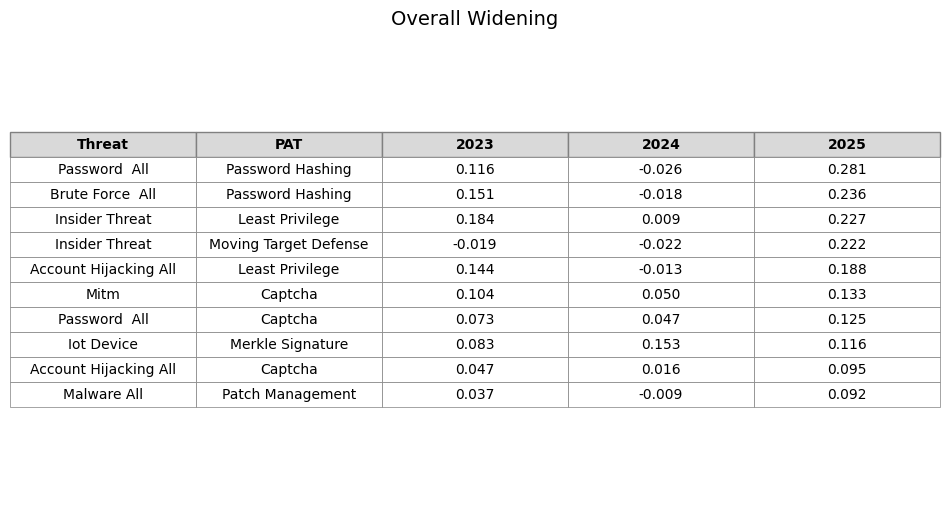

Saved: Overall_Widening.png (and archived to archive/)

--- Table 5b: Overall Widening Gaps (Top 5) ---
               Threat                   PAT   2023   2024  2025
        Password  All      Password Hashing  0.116 -0.026 0.281
     Brute Force  All      Password Hashing  0.151 -0.018 0.236
       Insider Threat       Least Privilege  0.184  0.009 0.227
       Insider Threat Moving Target Defense -0.019 -0.022 0.222
Account Hijacking All       Least Privilege  0.144 -0.013 0.188


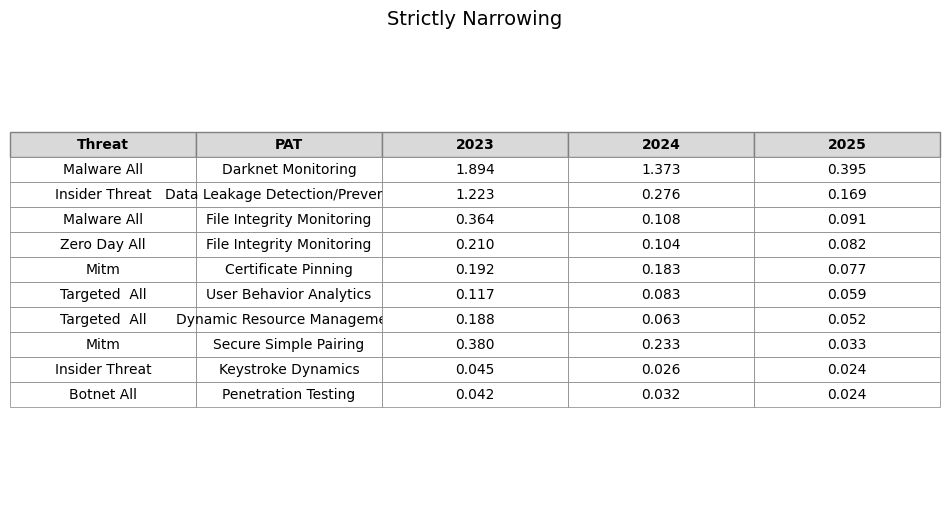

Saved: Strictly_Narrowing.png (and archived to archive/)

--- Table 6a: Strictly Narrowing Gaps (Top 5) ---
        Threat                               PAT  2023  2024  2025
   Malware All                Darknet Monitoring 1.894 1.373 0.395
Insider Threat Data Leakage Detection/Prevention 1.223 0.276 0.169
   Malware All         File Integrity Monitoring 0.364 0.108 0.091
  Zero Day All         File Integrity Monitoring 0.210 0.104 0.082
          Mitm               Certificate Pinning 0.192 0.183 0.077


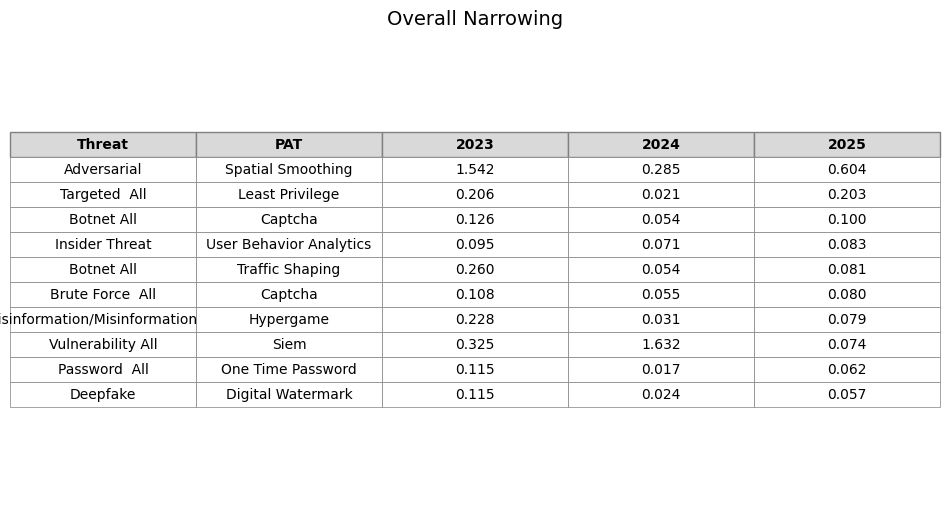

Saved: Overall_Narrowing.png (and archived to archive/)

--- Table 6b: Overall Narrowing Gaps (Top 5) ---
        Threat                     PAT  2023  2024  2025
   Adversarial       Spatial Smoothing 1.542 0.285 0.604
 Targeted  All         Least Privilege 0.206 0.021 0.203
    Botnet All                 Captcha 0.126 0.054 0.100
Insider Threat User Behavior Analytics 0.095 0.071 0.083
    Botnet All         Traffic Shaping 0.260 0.054 0.081

--- PAPER FIG 4: Continuous Trends ---


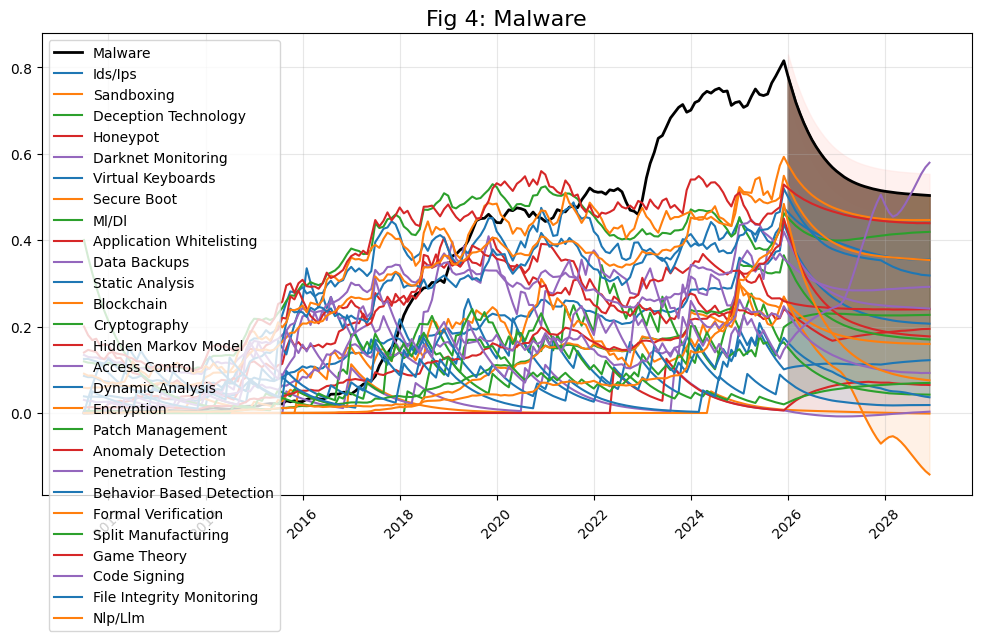

Saved: Fig4_Malware.png (and archived to archive/)


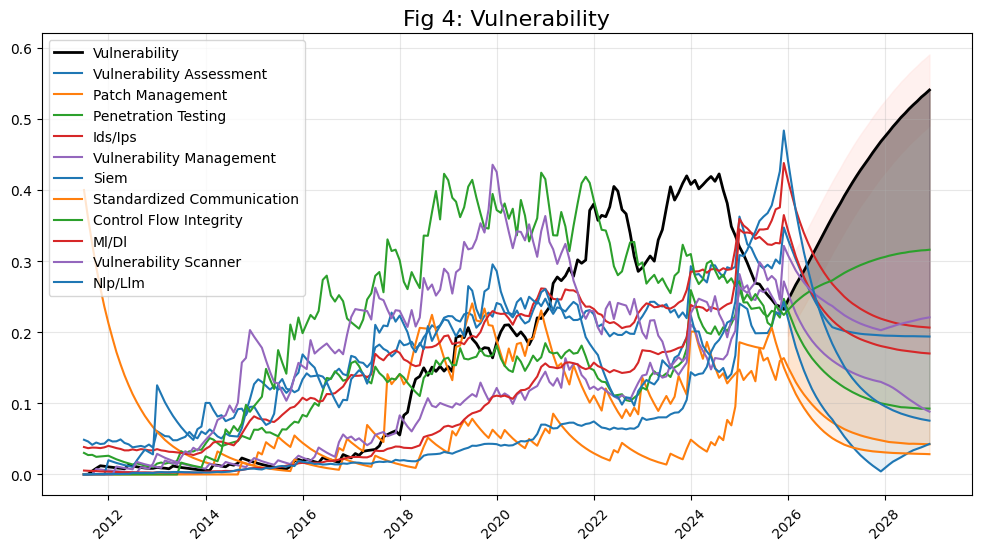

Saved: Fig4_Vulnerability.png (and archived to archive/)


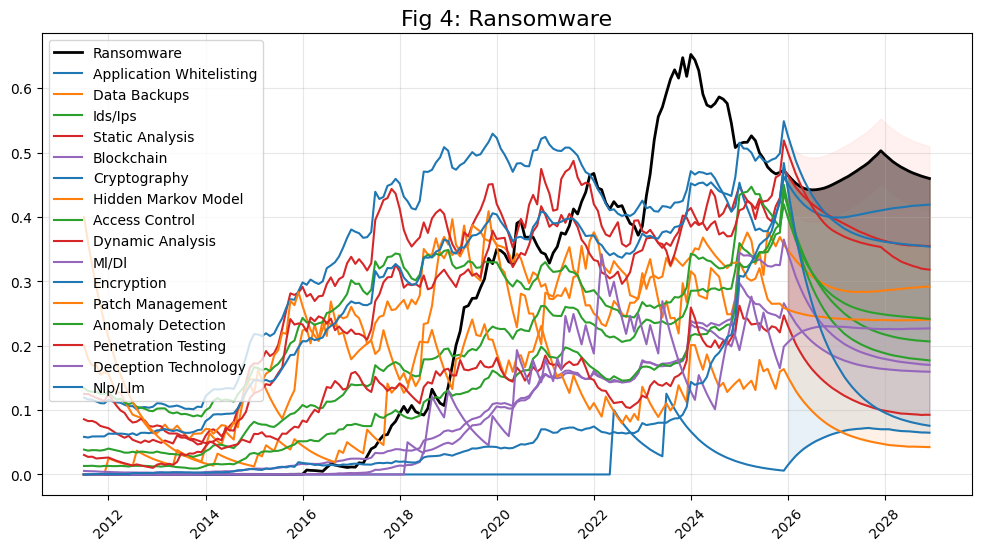

Saved: Fig4_Ransomware.png (and archived to archive/)


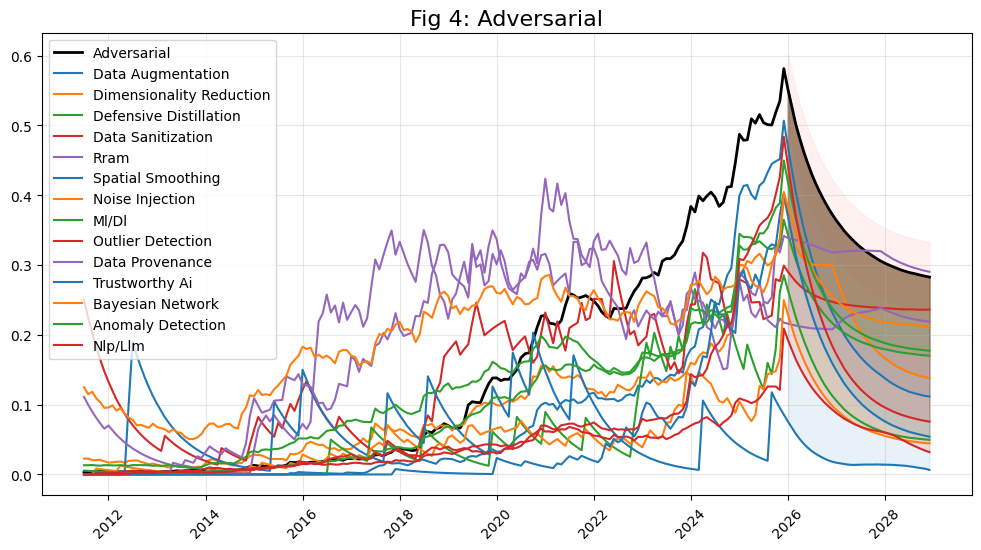

Saved: Fig4_Adversarial.png (and archived to archive/)

--- Generating Evaluation Metrics Table ---


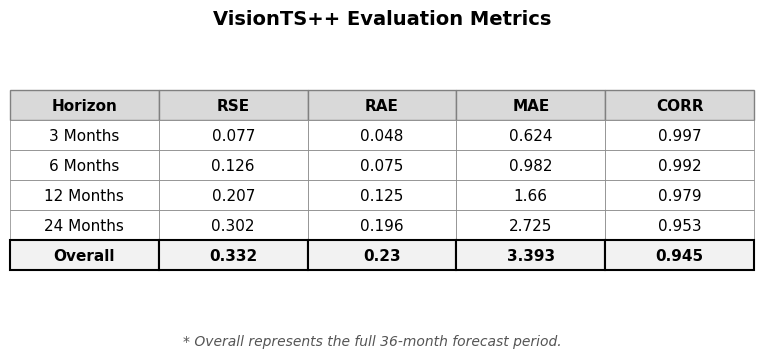

Saved: Vision_Eval_Table.png (and archived to archive/)


In [ ]:
%run Visualise_VisionPP_Results.py --dataset v2_2_full

## Appendix: Re-Run Training (Finetuning Does Not Beat Zero-Shot)

*Note: roughly 10-25 minutes on GPU/Apple Silicon.*

In [ ]:
import shutil

# 0. The demo needs the 159-feature windows. Build them if missing.
V22_NPZ = os.path.join('..', 'Processed_Data', 'visionpp', 'v2_2', 'test.npz')
if not os.path.exists(V22_NPZ):
    print('--- Building v2_2 preprocessed windows (pinned 159 features) ---')
    !{sys.executable} -W ignore -m Preprocessing.Cyber_Trend_to_Image \
        --dataset v2_2 \
        --window-first \
        --feature-names-file Preprocessing/v2_1_selected_features_159.txt 2>/dev/null
    !{sys.executable} -W ignore -m Preprocessing.Cyber_Trend_to_Image_PP \
        --dataset v2_2 --force 2>/dev/null
    print('--- Generating the zero-shot reference arrays ---')
    %run Evaluate_VisionPP.py --dataset v2_2

# 1. Snapshot the zero-shot arrays for the comparison.
DEMO_DIR = os.path.join('Results', 'v2_2', 'training_demo')
os.makedirs(DEMO_DIR, exist_ok=True)
for src, dst in [('visionpp_predictions.npy', 'zeroshot_predictions.npy'),
                 ('visionpp_ground_truth.npy', 'zeroshot_ground_truth.npy')]:
    shutil.copyfile(os.path.join('Results', 'v2_2', src),
                    os.path.join(DEMO_DIR, dst))
print('Zero-shot arrays snapshotted to', DEMO_DIR)

# 2. Finetune
print('\n--- Appendix: finetuning ---')
%run Train_VisionPP.py --dataset v2_2 --epochs 10 --batch_size 8

Zero-shot arrays snapshotted to Results/v2_2/training_demo

--- Appendix: finetuning under the canonical geometry (159 width) ---
Random seed: 123
Main Loop: Running best of 1 initialisation(s)
Using device: mps

--- Loading Preprocessed Data ---
Data directory: Processed_Data/visionpp/v2_2
Initializing VisionTS dataset for split: train from Processed_Data/visionpp/v2_2
Loading windowed data from Processed_Data/visionpp/v2_2/train.npz...
Loaded 44 samples for train.
  X shape: (44, 36, 159) (samples, context_len, nvars)
  y shape: (44, 36, 159) (samples, pred_len, nvars)
Initializing VisionTS dataset for split: val from Processed_Data/visionpp/v2_2
Loading windowed data from Processed_Data/visionpp/v2_2/val.npz...
Loaded 31 samples for val.
  X shape: (31, 36, 159) (samples, context_len, nvars)
  y shape: (31, 36, 159) (samples, pred_len, nvars)
Initializing VisionTS dataset for split: test from Processed_Data/visionpp/v2_2
Loading windowed data from Processed_Data/visionpp/v2_2/test.n

Load Processed_Data/visionpp/v2_2/ckpt/visiontspp_model.ckpt
  - Periodicity: 1
  - Norm const: 0.4
  - Align const: 0.4
  - Chunk size: 6
VisionTS++ initialized. Parameters: 55,808 trainable / 115,059,712 total



Starting VisionTS++ Training



Epoch 1/10:   0%|          | 0/5 [00:00<?, ?it/s]


Epoch 1/10:   0%|          | 0/5 [00:13<?, ?it/s, loss=2658.5593]

...


Testing:  50%|#####     | 2/4 [00:03<00:03,  1.75s/it]


Testing:  75%|########  | 3/4 [00:05<00:01,  1.67s/it]


Testing: 100%|##########| 4/4 [00:06<00:00,  1.36s/it]


Testing: 100%|##########| 4/4 [00:06<00:00,  1.51s/it]


Test Results
RSE:         0.298369
RAE:         0.193746
MSE:         2075.262207
MAE:         9.098379
RMSE:        45.555046
Correlation: 0.016159

Results saved to Processed_Data/visionpp/v2_2


In [ ]:
# 3. Evaluate the finetuned checkpoint
print('--- Appendix: evaluating the finetuned checkpoint ---')
%run Evaluate_VisionPP.py --dataset v2_2

--- Appendix: evaluating the finetuned checkpoint ---
--- Loading Test Data from Processed_Data/visionpp/v2_2 ---
Initializing VisionTS dataset for split: test from Processed_Data/visionpp/v2_2
Loading windowed data from Processed_Data/visionpp/v2_2/test.npz...
Loaded 28 samples for test.
  X shape: (28, 36, 159) (samples, context_len, nvars)
  y shape: (28, 36, 159) (samples, pred_len, nvars)
Test samples: 28
Dimensions: context=36, pred=36, features=159
Using device: mps

--- Loading VisionTS++ Model ---
Init VisionTS++ wrapper:
  - Architecture: mae_base
  - Fine-tune type: ln
  - Context length: 36
  - Prediction length: 36
  - Number of features: 159
  - Quantile prediction: True
  - Color encoding: True


Load Processed_Data/visionpp/v2_2/ckpt/visiontspp_model.ckpt


  - Periodicity: 1
  - Norm const: 0.4
  - Align const: 0.4
  - Chunk size: 6
VisionTS++ initialized. Parameters: 55,808 trainable / 115,059,712 total


Loaded weights from Processed_Data/visionpp/v2_2/checkpoints/visiontspp/visiontspp_best.pt
  Checkpoint epoch: 0
  Checkpoint val_loss: 1247.155762

--- Running Inference ---


Predictions shape: (28, 36, 159)
Ground truth shape: (28, 36, 159)

--- Calculating Metrics per Horizon ---

Evaluation Results
  Horizon      RSE      RAE      MAE     CORR
 3 Months 0.074400 0.038801 1.568369 0.997274
 6 Months 0.128570 0.063355 2.581196 0.991802
12 Months 0.208443 0.108765 4.533270 0.978100
24 Months 0.288208 0.172943 7.675293 0.958280
  Overall 0.298369 0.193746 9.098379 0.959059

Saved results table to Transformer_Pipeline/Results/v2_2/visionpp_evaluation_results.csv

--- Saving Raw Predictions ---
Saved prediction arrays to Transformer_Pipeline/Results/v2_2/
Saved prediction arrays to Processed_Data/visionpp/v2_2/

--- Data Preprocessing Summary ---
Original features: 1231


In [ ]:
# 4. Side-by-side comparison: zero-shot (snapshot) vs finetuned.
def pfcorr(p, t, h):
    cs = [np.corrcoef(p[:, :h, k].ravel(), t[:, :h, k].ravel())[0, 1]
          for k in range(p.shape[2])
          if p[:, :h, k].std() > 0 and t[:, :h, k].std() > 0]
    return float(np.mean(cs))


def rae(p, t, h):
    pf, tf = p[:, :h, :].ravel(), t[:, :h, :].ravel()
    return float(np.mean(np.abs(pf - tf))
                 / (np.mean(np.abs(tf - np.mean(tf))) + 1e-7))


zs_p = np.load(os.path.join(DEMO_DIR, 'zeroshot_predictions.npy'))
zs_t = np.load(os.path.join(DEMO_DIR, 'zeroshot_ground_truth.npy'))
ft_p = np.load(os.path.join('Results', 'v2_2', 'visionpp_predictions.npy'))
ft_t = np.load(os.path.join('Results', 'v2_2', 'visionpp_ground_truth.npy'))
assert np.allclose(zs_t, ft_t), 'ground-truth mismatch between the two runs'

rows = []
for name, p in [('zero-shot', zs_p), ('finetuned (demo)', ft_p)]:
    for set_name, slc in [('imputation_free', slice(0, 17)), ('all_windows', slice(None))]:
        row = {'model': name, 'window_set': set_name}
        for h in (3, 12, 36):
            row[f'PFCORR_h{h}'] = round(pfcorr(p[slc], zs_t[slc], h), 4)
            row[f'RAE_h{h}'] = round(rae(p[slc], zs_t[slc], h), 4)
        rows.append(row)

display(pd.DataFrame(rows).set_index(['window_set', 'model']).sort_index())

In [ ]:
# 5. Restore the archived zero-shot state.
demo_checkpoints = [
    Path('..') / 'Processed_Data' / 'visionpp' / 'v2_2' / 'checkpoints'
        / 'visiontspp' / 'visiontspp_best.pt',
    Path('Models') / 'best_model_visionpp_v2_2.pth',
]
for ckpt in demo_checkpoints:
    if ckpt.exists():
        ckpt.unlink()
        print(f'Removed demo checkpoint: {ckpt}')

print('\n--- Restoring archived zero-shot arrays ---')
%run Evaluate_VisionPP.py --dataset v2_2

restored = np.load(os.path.join('Results', 'v2_2', 'visionpp_predictions.npy'))
snapshot = np.load(os.path.join(DEMO_DIR, 'zeroshot_predictions.npy'))
ok = np.allclose(restored, snapshot, atol=1e-5)
print(f'\nArchived zero-shot state restored and verified: {ok}')
assert ok, 'Restored arrays differ from the zero-shot snapshot'

Removed demo checkpoint: ../Processed_Data/visionpp/v2_2/checkpoints/visiontspp/visiontspp_best.pt
Removed demo checkpoint: Models/best_model_visionpp_v2_2.pth

--- Restoring archived zero-shot arrays (deterministic re-run) ---
--- Loading Test Data from Processed_Data/visionpp/v2_2 ---
Initializing VisionTS dataset for split: test from Processed_Data/visionpp/v2_2
Loading windowed data from Processed_Data/visionpp/v2_2/test.npz...
Loaded 28 samples for test.
  X shape: (28, 36, 159) (samples, context_len, nvars)
  y shape: (28, 36, 159) (samples, pred_len, nvars)
Test samples: 28
Dimensions: context=36, pred=36, features=159
Using device: mps

--- Loading VisionTS++ Model ---
Init VisionTS++ wrapper:
  - Architecture: mae_base
  - Fine-tune type: ln
  - Context length: 36
  - Prediction length: 36
  - Number of features: 159
  - Quantile prediction: True
  - Color encoding: True


Load Processed_Data/visionpp/v2_2/ckpt/visiontspp_model.ckpt
  - Periodicity: 1
  - Norm const: 0.4
  - Align const: 0.4
  - Chunk size: 6
VisionTS++ initialized. Parameters: 55,808 trainable / 115,059,712 total
Running with pretrained weights only.

--- Running Inference ---


Predictions shape: (28, 36, 159)
Ground truth shape: (28, 36, 159)

--- Calculating Metrics per Horizon ---

Evaluation Results
  Horizon      RSE      RAE      MAE     CORR
 3 Months 0.074126 0.038400 1.552143 0.997276
 6 Months 0.128561 0.062827 2.559702 0.991772
12 Months 0.208196 0.107993 4.501104 0.978130
24 Months 0.287448 0.171833 7.626016 0.958649
  Overall 0.298520 0.192791 9.053495 0.959427

Saved results table to Transformer_Pipeline/Results/v2_2/visionpp_evaluation_results.csv

--- Saving Raw Predictions ---
Saved prediction arrays to Transformer_Pipeline/Results/v2_2/
Saved prediction arrays to Processed_Data/visionpp/v2_2/

--- Data Preprocessing Summary ---
Original features: 1231

Archived zero-shot state restored and verified: True
